In [10]:
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torchaudio
from IPython.display import Audio, display
from hydra.utils import instantiate

from src.utils.audio_io import load_audio, save_audio

CHECKPOINT_URL = "https://huggingface.co/dimadmitrij734/bdz_first/resolve/main/model_best.pth"
CHECKPOINT_PATH = Path("checkpoints/model_best.pth")
TEST_ROOT = Path("/kaggle/input/datasets/a24998667/librispeech/test-clean/LibriSpeech/test-clean")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_RATE = 16000

OUTPUT_DIR = Path("outputs/analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
urlretrieve(CHECKPOINT_URL, CHECKPOINT_PATH)

print("device:", DEVICE)
print("checkpoint:", CHECKPOINT_PATH)


device: cuda
checkpoint: checkpoints/model_best.pth


Загружаем саму нашу уже обученную модель с hugging face

In [11]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model = instantiate(checkpoint["config"].model).to(DEVICE)
model.load_state_dict(checkpoint["model"], strict=False)
model.eval()

print("checkpoint step:", checkpoint.get("step"))
print("best STOI during training:", checkpoint.get("best_stoi"))


checkpoint step: 40000
best STOI during training: 0.9102436707723008


In [17]:
def reconstruct(audio: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        audio = audio.unsqueeze(0).to(DEVICE)
        reconstructed = model(audio)["audio_hat"].squeeze(0).cpu()
    return reconstructed


def load_any(path: Path) -> torch.Tensor:
    return load_audio(path, SAMPLE_RATE)


def download(url: str, path: Path) -> Path:
    from urllib.request import Request, urlopen

    path.parent.mkdir(parents=True, exist_ok=True)
    request = Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0 (compatible; SoundStreamAnalysis/1.0; +https://github.com/nikuradzedima/dl_bdz)"
        },
    )
    with urlopen(request, timeout=60) as response:
        path.write_bytes(response.read())
    return path


def plot_pair(original: torch.Tensor, reconstructed: torch.Tensor, title: str, out_path: Path):
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    for col, (name, audio) in enumerate([("original", original), ("reconstructed", reconstructed)]):
        waveform = audio[0].numpy()
        axes[0, col].plot(waveform)
        axes[0, col].set_title(f"{title}: {name} waveform")
        spec = torch.stft(
            audio[0],
            n_fft=512,
            hop_length=128,
            window=torch.hann_window(512),
            return_complex=True,
        ).abs()
        axes[1, col].imshow((spec + 1e-7).log().numpy(), origin="lower", aspect="auto")
        axes[1, col].set_title(f"{title}: {name} log STFT")
    fig.tight_layout()
    fig.savefig(out_path, dpi=140)
    plt.show()
    return out_path


def spectral_l1(original: torch.Tensor, reconstructed: torch.Tensor) -> float:
    window = torch.hann_window(512)
    o = torch.stft(original[0], n_fft=512, hop_length=128, window=window, return_complex=True).abs()
    r = torch.stft(reconstructed[0], n_fft=512, hop_length=128, window=window, return_complex=True).abs()
    return torch.nn.functional.l1_loss((o + 1e-7).log(), (r + 1e-7).log()).item()


def summarize(original: torch.Tensor, reconstructed: torch.Tensor, name: str) -> dict:
    return {
        "sample": name,
        "mae": torch.nn.functional.l1_loss(reconstructed, original).item(),
        "spectral_l1": spectral_l1(original, reconstructed),
    }


Построим графики восстановленного и исходного сигнала и сравним их.

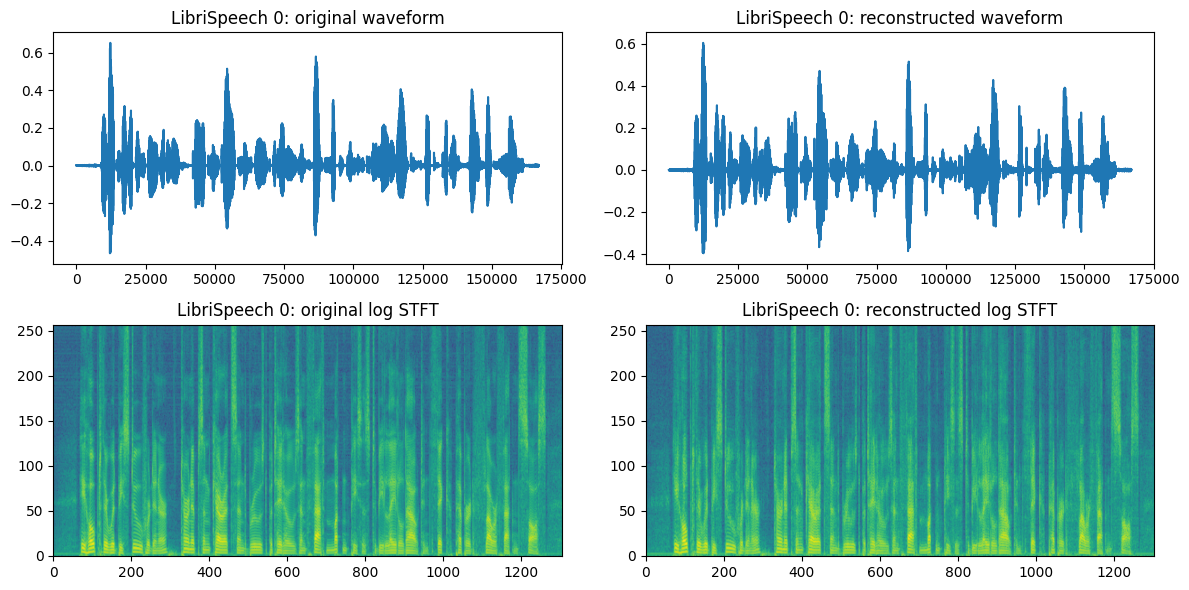

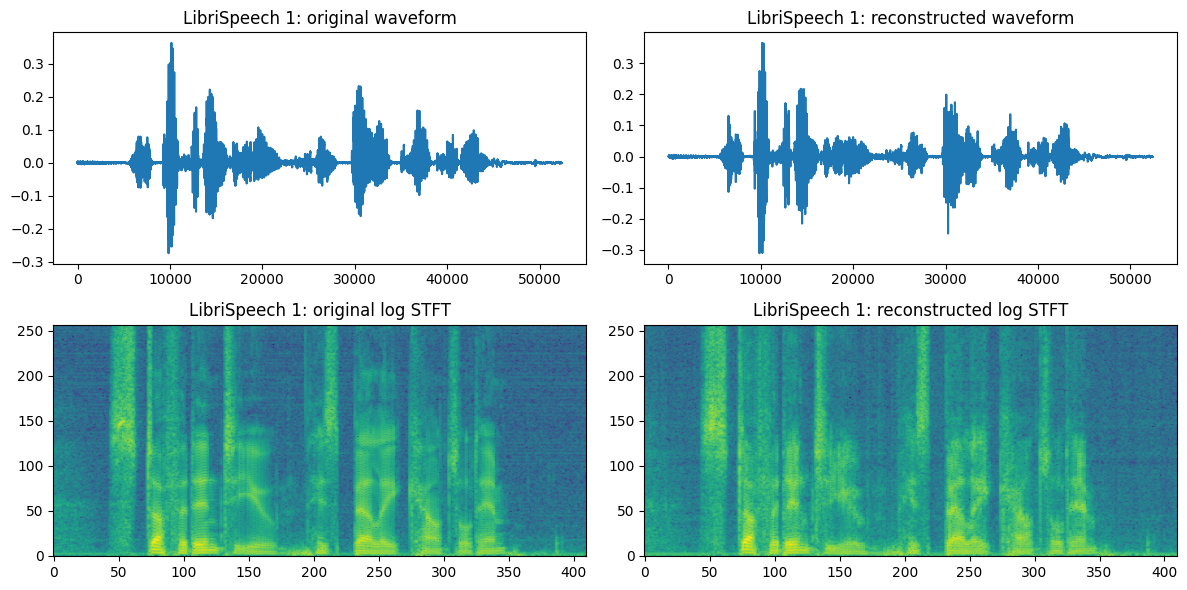

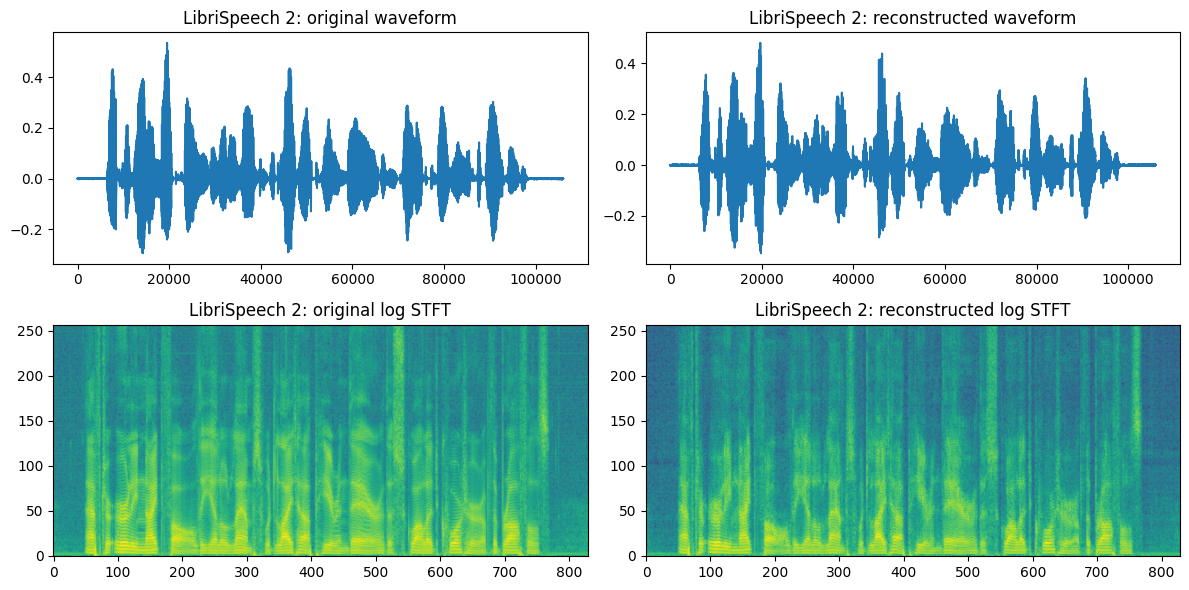

                  sample       mae  spectral_l1
0  1089-134686-0000.flac  0.013219     0.774569
1  1089-134686-0001.flac  0.009604     0.745868
2  1089-134686-0002.flac  0.015542     0.778052


In [18]:
libri_files = sorted(TEST_ROOT.rglob("*.flac"))[:3]
libri_rows = []

for idx, path in enumerate(libri_files):
    original = load_any(path)
    reconstructed = reconstruct(original)
    out_path = OUTPUT_DIR / f"librispeech_{idx}.png"
    plot_pair(original, reconstructed, f"LibriSpeech {idx}", out_path)
    save_audio(OUTPUT_DIR / f"librispeech_{idx}_original.wav", original, SAMPLE_RATE)
    save_audio(OUTPUT_DIR / f"librispeech_{idx}_reconstructed.wav", reconstructed, SAMPLE_RATE)
    libri_rows.append(summarize(original, reconstructed, path.name))
    display(Audio(original.numpy(), rate=SAMPLE_RATE))
    display(Audio(reconstructed.numpy(), rate=SAMPLE_RATE))

pd.DataFrame(libri_rows)


Форма и структура спектра в целом сохраняются. Для трех примеров `mae` находится примерно в диапазоне `0.0096-0.0155`, а `spectral_l1` — около `0.746-0.778`. Есть некоторые рассхождения, но они более менее мелкие, по самому звуку также в целом очень похоже получилось.


Дальше используется пример из LJ Speech. Это тоже английская речь, но другой диктор и другой источник записи, поэтому пример чуть дальше от обучающих данных.

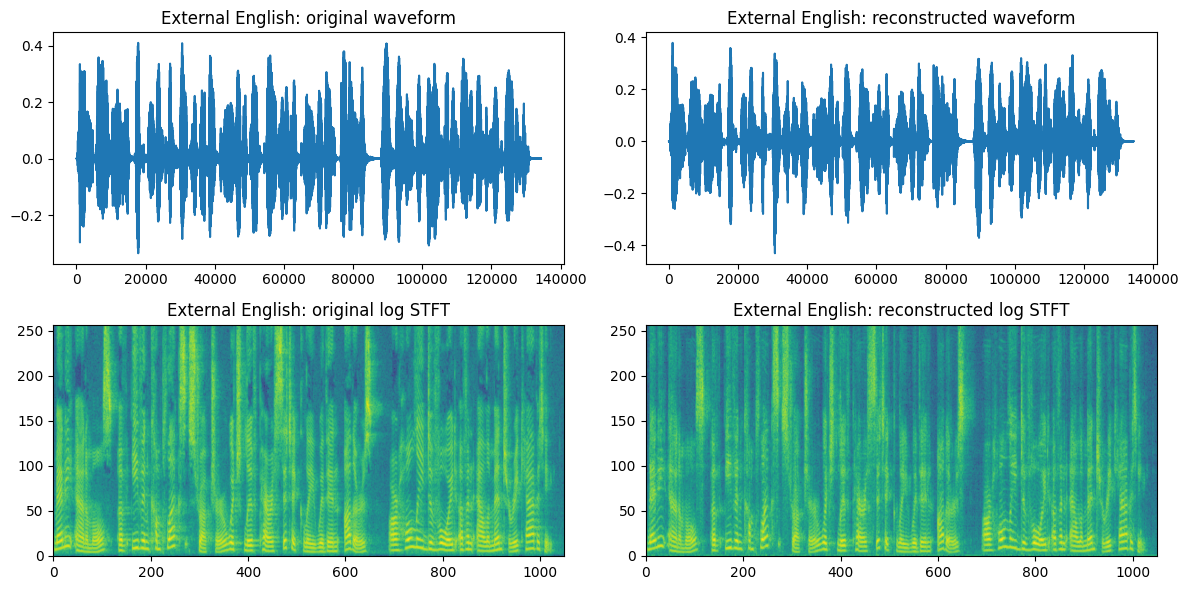

             sample       mae  spectral_l1
0  external_english  0.027106     0.929951


In [14]:
english_url = "https://keithito.com/LJ-Speech-Dataset/LJ025-0076.wav"
english_path = download(english_url, OUTPUT_DIR / "external_english.wav")
english_original = load_any(english_path)
english_reconstructed = reconstruct(english_original)
plot_pair(english_original, english_reconstructed, "External English", OUTPUT_DIR / "external_english.png")
save_audio(OUTPUT_DIR / "external_english_reconstructed.wav", english_reconstructed, SAMPLE_RATE)
display(Audio(english_original.numpy(), rate=SAMPLE_RATE))
display(Audio(english_reconstructed.numpy(), rate=SAMPLE_RATE))
pd.DataFrame([summarize(english_original, english_reconstructed, "external_english")])


Тут также codec продолжает восстанавливать разборчивую речь, но ошибка выше, чем на примерах LibriSpeech. Здесь `mae = 0.0271`, `spectral_l1 = 0.9300`.

Это ожидаемо, так как по сути модель обучалась на LibriSpeech, поэтому на другом дикторе и другой записи артефакты могут быть заметнее.


Для проверки на другом языке используется короткая запись русского алфавита с Wikimedia Commons.

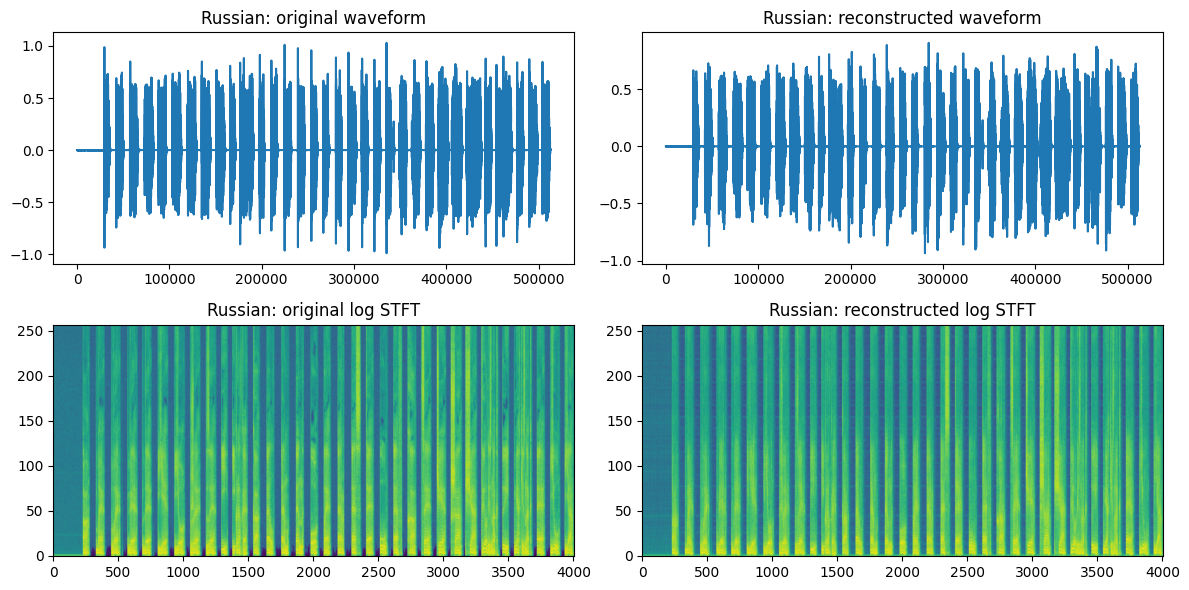

    sample       mae  spectral_l1
0  russian  0.057289      0.97709


In [19]:
russian_url = "https://upload.wikimedia.org/wikipedia/commons/2/24/Russian_alphabet.ogg"
russian_path = download(russian_url, OUTPUT_DIR / "russian.ogg")
russian_original = load_any(russian_path)
russian_reconstructed = reconstruct(russian_original)
plot_pair(russian_original, russian_reconstructed, "Russian", OUTPUT_DIR / "russian.png")
save_audio(OUTPUT_DIR / "russian_reconstructed.wav", russian_reconstructed, SAMPLE_RATE)
display(Audio(russian_original.numpy(), rate=SAMPLE_RATE))
display(Audio(russian_reconstructed.numpy(), rate=SAMPLE_RATE))
pd.DataFrame([summarize(russian_original, russian_reconstructed, "russian")])


Модель все равно восстанавливает звук, потому что codec работает с акустическим сигналом, а не с текстом. Но искажения здесь сильнее, а именно `mae = 0.0573`, `spectral_l1 = 0.9771`.

Такой результат тоже логичен, ведь модель обучалась на английской речи LibriSpeech, а русский пример отличается языком, диктором, записью и распределением звуков.


Прогоним модель на первых 20 файлах `LibriSpeech test-clean` и посчитаем статистики.


In [20]:
quant_files = sorted(TEST_ROOT.rglob("*.flac"))[:20]
quant_rows = []

for path in quant_files:
    original = load_any(path)
    reconstructed = reconstruct(original)
    quant_rows.append(summarize(original, reconstructed, path.name))

quant_df = pd.DataFrame(quant_rows)
quant_df.describe()


             mae  spectral_l1
count  20.000000    20.000000
mean    0.013297     0.768002
std     0.004403     0.017843
min     0.008983     0.745868
25%     0.011010     0.757293
50%     0.011751     0.764503
75%     0.013241     0.771971
max     0.024278     0.821779


Средний `mae = 0.0133`, средний `spectral_l1 = 0.7680`. Тут ошибка поменьше чем на русском тексте и больше чем на тексте, который меньше похож на обучающуюся выборку, но все равно присутствует. Но мы также считали и на всей выборке, а там основные метрики получились следующими, а именно `STOI = 0.9070` и `NISQA = 3.6354`. Мы выбили метрики выше, чем требовалось, что в частности говорит о том, что моделька все таки обучилась довольно хорошо.

Как мы можем заметить, модель решает основную задачу, то есть сжимает речь в дискретное представление через RVQ и восстанавливает обратно. На данных LibriSpeech качество лучше всего, на внешней английской речи и на русском тексте качество немного хуже. То есть мы все таки немного подстраиваемся под обучающую выборку, но что в целом неудивительно.
